# Práctica 10: El Lector de Dígitos
**De las matrices a la Inteligencia Artificial**

En esta práctica vamos a unir todo lo que sabemos de la UT4 (Matrices, Píxeles, OpenCV) con la teoría que vimos en la UT3 (Machine Learning).
Vamos a entrenar una Inteligencia Artificial para que aprenda a leer números escritos a mano.

**Herramientas de hoy:**
* `sklearn`: La librería Scikit-Learn. Nuestro motor de Machine Learning.
* `matplotlib`: Para visualizar gráficamente los números y resultados.

In [33]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Importamos las herramientas de Scikit-Learn que usaremos hoy
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Parte 1: Explorando el Dataset
Scikit-Learn viene con un dataset de "juguete" llamado `digits`. Contiene miles de imágenes de $8 \times 8$ píxeles de números escritos a mano. 

**OJO:** A diferencia de las imágenes normales (donde el blanco es 255), en este dataset en concreto los píxeles van del **0 (Negro)** al **16 (Blanco)**.

Tenemos 1797 imágenes, cada una de 8x8 píxeles.


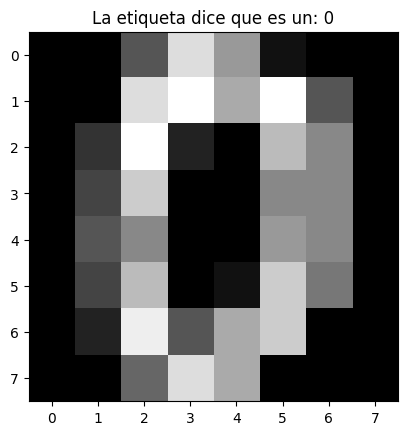

In [34]:
# Cargar el dataset de imágenes
digitos = datasets.load_digits()
imagenes_crudas = digitos.images  # Matrices 2D (Las fotos)
etiquetas = digitos.target        # Las respuestas correctas (0 al 9)

# 1. Mira la forma de 'imagenes_crudas' para entender qué tenemos.
forma_dataset = imagenes_crudas.shape
print(f"Tenemos {forma_dataset[0]} imágenes, cada una de {forma_dataset[1]}x{forma_dataset[2]} píxeles.")

# Vamos a dibujar la primera imagen
plt.imshow(imagenes_crudas[0], cmap='gray')
plt.title(f"La etiqueta dice que es un: {etiquetas[0]}")
plt.show()

## Parte 2: Preparando los Datos para la IA
Recordemos la teoría: nuestro modelo de IA (KNN) no entiende de matrices $8 \times 8$. Solo entiende de **vectores planos (1D)**.
Además, a las IAs no les gustan los números grandes. Tenemos que **Normalizar** dividiendo entre el valor máximo (en este caso 16.0, no 255).

In [35]:
# 1. FLATTENING (Aplanamiento)
# Queremos pasar de la forma (1797, 8, 8) a (1797, 64)
X_aplanado = imagenes_crudas.reshape((forma_dataset[0], 64))

# 2. NORMALIZACIÓN
# Queremos que los valores pasen de 0-16 a 0.0-1.0
X_normalizado = X_aplanado / 16

print("Datos aplanados y normalizados")
print(f"Nueva forma de X: {X_normalizado.shape}")

Datos aplanados y normalizados
Nueva forma de X: (1797, 64)


## Parte 3: Entrenando la Inteligencia Artificial (Líneas de código completas)
Ahora viene la magia de la UT3. Vamos a:
1. Dividir los datos: unos pocos para enseñar a la IA (Train) y otros para examinarla (Test).
2. Crear un modelo `KNeighborsClassifier`.
3. Entrenarlo usando el método `.fit()`.

In [36]:
# 1. Divide los datos usando train_test_split (80% train, 20% test)
# PISTA: Recuerda pasarle X_normalizado y las etiquetas. Usa random_state=42 para que a todos nos dé igual.
X_train, X_test, y_train, y_test = train_test_split(X_normalizado, etiquetas, test_size = 20, train_size = 80, random_state = 42)

# 2. Crea tu modelo KNN (KNeighborsClassifier) con n_neighbors=3
mi_ia = KNeighborsClassifier(n_neighbors = 3)

# 3. Entrena la IA pasándole los datos de entrenamiento (X_train, y_train)
mi_ia.fit(X_train, y_train)

print("¡Entrenamiento completado en milisegundos!")

¡Entrenamiento completado en milisegundos!


## Parte 4: Evaluación y Matriz de Confusión
Nuestra IA ya ha estudiado. Ahora vamos a pasarle el examen final (`X_test`) a ver qué predice (`predict`), y compararemos sus respuestas con las verdaderas (`y_test`) dibujando una Matriz de Confusión.

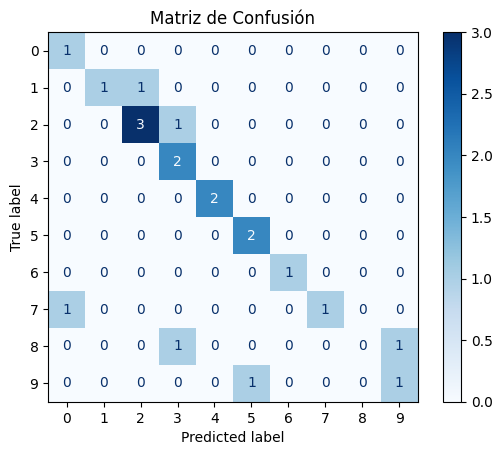

In [37]:
# 1. Pide a la IA que haga predicciones sobre los datos de examen (X_test)
predicciones = mi_ia.predict(X_test)

# 2. Calcula la matriz de confusión (compara y_test con las predicciones)
matriz = confusion_matrix(y_test, predicciones)

# 3. Dibujamos la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

# PREGUNTA PARA TI: Observa el gráfico. ¿Qué número confunde más a menudo nuestra IA? ¿Por qué crees que pasa (recuerda la teoría del Flattening)?
# Confunde el 3 y el 8, el 5 y el 9... porque son formas parecidas y, al aplanar la imagen, el array queda bastante parecido al del número erróneo.

## Parte 5: EL RETO FINAL (OpenCV + Scikit-Learn)

**Misión:**
1. Abre Paint, haz un lienzo en blanco y dibuja un número del 0 al 9 con pincel grueso negro. Guárdalo en la misma carpeta del Notebook como `mi_numero.png`.
2. Escribe el código en la celda de abajo para:
   - Leer la foto con `cv2` (en blanco y negro).
   - Invertir los colores (`cv2.bitwise_not`), porque nuestro modelo aprendió con números blancos sobre fondo negro.
   - Redimensionar (`cv2.resize`) la imagen a $8 \times 8$ píxeles.
   - Aplicar el aplanamiento y la normalización adecuada (Cuidado: tu foto del Paint sí va de 0 a 255).
   - Pedirle a tu modelo IA (`mi_ia`) que prediga qué número es.

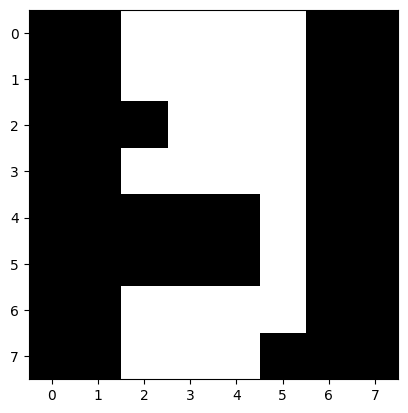

La IA cree que has dibujado un 9


In [55]:
# RETO FINAL: Carga 'mi_numero.png', procésala y pásasela a .predict()
img_num = cv2.imread('mi_numero.png')
img_num_gray = cv2.cvtColor(img_num, cv2.COLOR_BGR2GRAY)
img_num_gray_inv = cv2.bitwise_not(img_num_gray)
img_num_8x8 = cv2.resize(img_num_gray_inv, (8,8))

X_aplanado = img_num_8x8.reshape((1, 64))
X_normalizado = X_aplanado / 255


# Para comprobar si vas bien, descomenta esta línea para ver cómo quedó tu matriz de 8x8 procesada:
plt.imshow(img_num_8x8, cmap='gray'); plt.show()

# Pide la predicción e imprímela por pantalla:
prediccion_final = mi_ia.predict(X_normalizado)
print(f"La IA cree que has dibujado un {prediccion_final[0]}")